In [2]:
import h5py
import os
from pathlib import Path
import torch
import numpy as np
from typing import List
from matplotlib import pyplot as plt

current_dir = Path(os.getcwd())
h5_file1 = Path(current_dir, 'disc_dataset_full_zonal.h5')
h5_file2 = Path(current_dir, 'disc_dataset_full_uniform.h5')
h5_file3 = Path(current_dir, 'disc_dataset_edge_proximity_uniform.h5')
h5_file4 = Path(current_dir, 'disc_dataset_edge_proximity_zonal.h5')
h5_file5 = Path(current_dir, 'disc_dataset_edge_deriv_uniform.h5')
h5_file6 = Path(current_dir, 'disc_dataset_edge_deriv_zonal.h5')
if not h5_file1.is_file() or not h5_file2.is_file() or not h5_file3.is_file() or not h5_file4.is_file() or not h5_file5.is_file() or not h5_file6.is_file():
    raise FileNotFoundError("One or more HDF5 files not found in the current directory.")


In [10]:
def load_h5_pointsets(path: Path):
    """
    Load all datasets (geometries) from an HDF5 file.

    Each dataset is expected to be [N,5] = (E_X, E_Y, W_Stress, LBL, SBL).
    Returns a list of FloatTensors per geometry with shape [N,5].
    """
    sets: List[torch.Tensor] = []
    with h5py.File(path, "r") as f:
        dataset_names = sorted(list(f.keys()))
        print(f"Found {len(dataset_names)} datasets")
        print(f"Dataset names: {dataset_names}")
        for name in dataset_names:
            arr = f[name][:]  
            sets.append(arr)
    return sets


N samples: 5000
Sample keys: ['arc_length_mm', 'contour_arc_length_mm', 'contour_points_mm', 'contour_region_id', 'contour_zone_id', 'geometry_parameters_actual', 'life_raw', 'node_coords_mm', 'node_feature_names', 'node_features', 'param_offsets', 'phase_stress_eq', 'radial_breaks_mm', 'region_id', 'stress_max_vm', 'triangles', 'zone_id', 'zone_names']
Sample attrs: {'sample_id': np.int64(0), 'seed': np.int64(7000118)}
Coords shape: (480, 2)
Stress range: 187.9160403170356 625.8383765126057
Life range (log10): 7.396189876965998 16.93566762526841


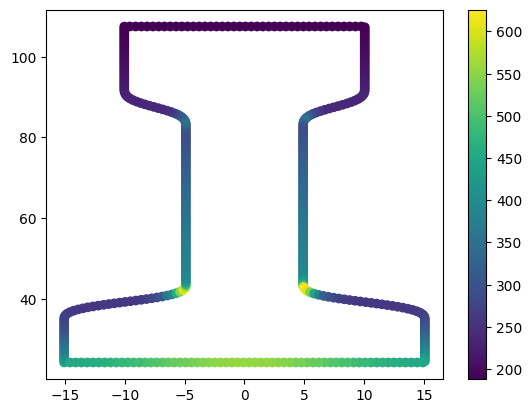

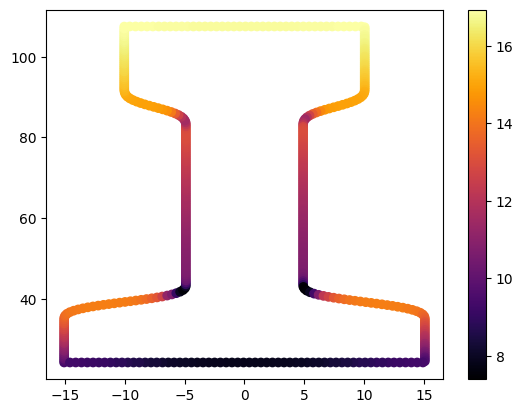

In [7]:
with h5py.File(h5_file5, "r") as f:
    # List all samples
    try:
        print("N samples:", len(f["samples"]))
    except (KeyError, OSError) as e:
        print(f"Warning: Could not read sample count: {e}")
        valid_count = sum(1 for name in f["samples"] if not isinstance(f["samples"].get(name, None), type(None)))
        print(f"Accessible samples (approximate): {valid_count}")
    
    # Inspect first sample
    s = f["samples"]["sample_000000"]
    print("Sample keys:", list(s.keys()))
    print("Sample attrs:", dict(s.attrs))
    
    # Read arrays
    try:
        coords = np.array(s["node_coords_mm"])
    except OSError as e:
        print(f"Failed to read 'node_coords_mm' for sample_000000: {e}")
        print("Trying to find the first readable sample...")
        coords = None
        for sample_name in f["samples"].keys():
            try:
                candidate = f["samples"][sample_name]
                coords = np.array(candidate["node_coords_mm"])
                s = candidate  # keep stress/life reads below aligned with coords
                print(f"Using fallback sample: {sample_name}")
                break
            except OSError:
                print(f"Failed to read 'node_coords_mm' for {sample_name}, trying next...")
                continue
        if coords is None:
            raise OSError("Could not read 'node_coords_mm' from any sample in this file.")
    stress = np.array(s["stress_max_vm"])
    life   = np.array(s["life_raw"])
    
    print("Coords shape:", coords.shape)
    print("Stress range:", stress.min(), stress.max())
    print("Life range (log10):", np.log10(life).min(), np.log10(life).max())
    plt.scatter(coords[:, 0], coords[:, 1], c=stress, cmap='viridis')
    plt.colorbar()
    plt.show()
    plt.scatter(coords[:, 0], coords[:, 1], c=np.log10(life), cmap='inferno')
    plt.colorbar()
    plt.show()

In [21]:
from pathlib import Path
from typing import List
import h5py
import numpy as np
import torch

def load_h5_pointsets(path: Path) -> List[torch.Tensor]:
    """
    Returns list of tensors, one per sample.
    
    Input columns (always):
        0: x (mm)
        1: r (mm)
        2: zone_id
    
    Input columns (edge only — arc_length present and fully valid):
        3: arc_length_mm
        4: tangent_x          (if derivatives stored)
        5: tangent_r          (if derivatives stored)
        6: curvature          (if derivatives stored)
        7: curvature_gradient (if derivatives stored)
    
    Target columns (always last):
        -2: stress_max_vm
        -1: life_raw
    """
    sets: List[torch.Tensor] = []

    with h5py.File(path, "r") as f:
        print("N samples:", len(f["samples"]))
        for name in sorted(f["samples"].keys()):
            grp = f["samples"][name]

            coords   = grp["node_coords_mm"][:]
            zone_id  = grp["zone_id"][:].astype(np.float32)
            stress   = grp["stress_max_vm"][:]
            life     = grp["life_raw"][:]

            columns = [
                coords[:, 0],  # x
                coords[:, 1],  # r
                zone_id,
            ]

            # Arc length only if present and fully valid (i.e. pure edge representation)
            if "arc_length_mm" in grp:
                arc = grp["arc_length_mm"][:].astype(np.float32)
                if not np.any(np.isnan(arc)):
                    columns.append(arc)

            # Derivative features only if stored and non-empty
            node_features = grp["node_features"][:]
            if node_features.shape[1] > 0:
                for i in range(node_features.shape[1]):
                    columns.append(node_features[:, i].astype(np.float32))

            columns.append(stress)
            columns.append(life)

            arr = np.stack(columns, axis=-1).astype(np.float32)
            sets.append(torch.tensor(arr, dtype=torch.float32))

    return sets

pointsets = load_h5_pointsets(h5_file1)
print(f"Loaded {len(pointsets)} pointsets")
print("First pointset shape:", pointsets[0].shape)

        

N samples: 5000
Loaded 5000 pointsets
First pointset shape: torch.Size([8830, 5])


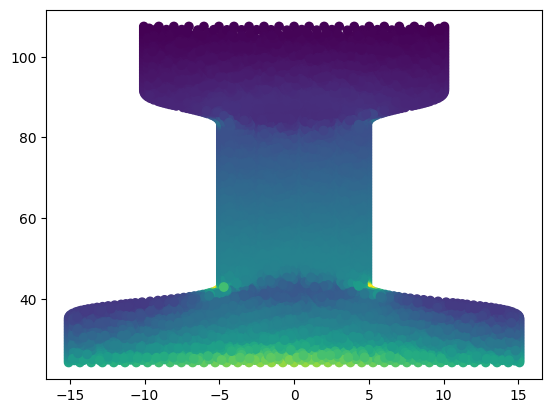

In [20]:
plt.scatter(pointsets[0][:, 0], pointsets[0][:, 1], c=pointsets[0][:, 5], cmap='viridis')